In [1]:
import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils import *


# 1 coherent state, contrast

In [12]:

t_rise = 30
square_t_stop = 733
area_under_square  = square_t_stop
area_under_rise_and_fall = t_rise
t_stop = 2 * t_rise + (square_t_stop-area_under_rise_and_fall)

tot_time = int(t_stop + 20)
tlist = np.linspace(0, tot_time, tot_time)

In [4]:

all_results = []
for i in range(8):
    with open(f'../pickles/mcsolve_three_outcome_state{i}_summed_padd_back.pkl', 'rb') as file:
        result = pickle.load(file)
    all_results.append(result)

results = [all_results[0],all_results[2],all_results[3],all_results[1]]

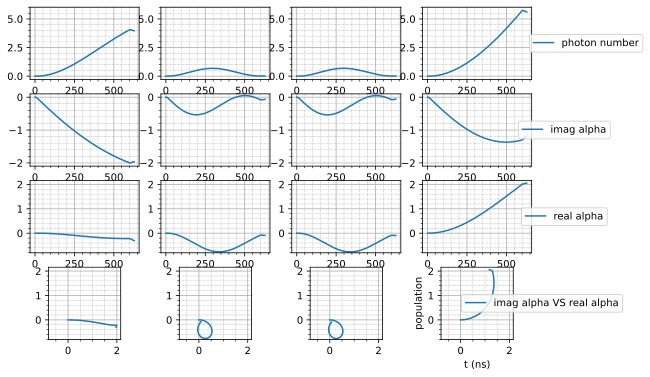

In [5]:



first_dominant_freq =find_dominant_frequency(results[0].expect[0],tlist)

nlevels = 4

fig, axes = plt.subplots(4,nlevels, figsize=(9, 6))

for i in range(nlevels):
    alpha = results[i].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)

    # Coherent state eigenval
    real = alpha.real
    imag = alpha.imag
    axes[1][i].plot(tlist,imag , label=r"imag alpha")
    axes[2][i].plot(tlist, real, label=r"real alpha")
    axes[3][i].plot(-imag, real, label=r"imag alpha VS real alpha")
    
    # Photon number
    axes[0][i].plot(tlist, results[i].expect[-1], label=r"photon number")

axes[0][nlevels-1].legend(loc='center', ncol=1, bbox_to_anchor=(1.5, 0.5))
axes[1][nlevels-1].legend(loc='center', ncol=1, bbox_to_anchor=(1.3, 0.5))
axes[2][nlevels-1].legend(loc='center', ncol=1, bbox_to_anchor=(1.3, 0.5))
axes[3][nlevels-1].legend(loc='center', ncol=1, bbox_to_anchor=(1.4, 0.5))
plt.ylabel("population")
plt.xlabel("t (ns)")
for row in [0,1,2,3]:
    max_x_range,min_x_range,max_y_range,min_y_range = 0,0,0,0
    for col in range(nlevels):
        ymin, ymax = axes[row][col].get_ylim()
        xmin, xmax = axes[row][col].get_xlim()
        if ymax > max_y_range:
            max_y_range = ymax
        if ymin < min_y_range:
            min_y_range = ymin
        if xmax > max_x_range:
            max_x_range = xmax
        if xmin < min_x_range:
            min_x_range = xmin
    for col in range(nlevels):
        axes[row][col].set_ylim(min_y_range, max_y_range)
        axes[row][col].set_xlim(min_x_range,max_x_range)
        # Set the third row y range equal x range
        if row == 3:
            axes[row][col].set_ylim(min(min_x_range,min_y_range), max(max_x_range,max_y_range))
            axes[row][col].set_xlim(min(min_x_range,min_y_range),max(max_x_range,max_y_range))
# plt.yscale('log')
for ax in axes.flat:
    ax.minorticks_on()
    ax.grid(True)
    ax.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
for col in axes[3]:
    col.set_aspect('equal', 'box')
plt.show()



 /tmp/ipykernel_470184/3361854022.py: 42

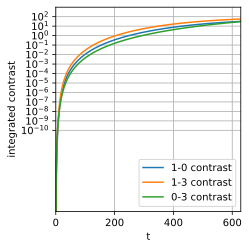

In [4]:
plt.figure(figsize=(3+3/8,3+3/8))
kappa_val = 1e-3

alpha1 = results[1].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
alpha0 = results[0].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
alpha3 = results[3].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)



squared_diff = np.square(abs(alpha0-alpha1))
integrals = [0.0]
for i in range(1,len(tlist)):
    integrals.append(integrals[i-1]+
                        (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                        )
    
plt.plot(tlist,integrals,label='1-0 contrast')

squared_diff = np.square(abs(alpha3-alpha1))
integrals = [0.0]
for i in range(1,len(tlist)):
    integrals.append(integrals[i-1]+
                        (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                        )
    
plt.plot(tlist,integrals,label='1-3 contrast')


squared_diff = np.square(abs(alpha3-alpha0))
integrals = [0.0]
for i in range(1,len(tlist)):
    integrals.append(integrals[i-1]+
                        (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                        )
    
plt.plot(tlist,integrals,label='0-3 contrast')



plt.legend(loc='lower right')
plt.yscale('log')
plt.ylim(0,1e3)
plt.yticks([1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1,1e1,1e2])
plt.xlim(0,tot_time)
plt.grid()
plt.tight_layout()
plt.xlabel('t')
plt.ylabel('integrated contrast')
# plt.savefig("fig06_integral.pdf", format='pdf', bbox_inches='tight')
plt.show()



# additional leakage due to state transfer

In [5]:

qubit_level = 25
osc_level = 50
kappa = 1e-3

system = fluxonium_oscillator_system(
        EJ = 2.5,
        EC = 0.65,
        EL = 0.12,
        Er = 7.05877808,
        g_strength = 0.2,
        qubit_level = qubit_level,
        osc_level = osc_level,
        kappa =kappa,
        products_to_keep=[[ql, ol] for ql in [0] for ol in range(45) ] + [[ql, ol] for ql in [7] for ol in range(30)],
        computaional_states = '1,2',
        w_d = 7.0585
        )

# interactive_heatmap(results[1], system.product_to_dressed, system.qbt.truncated_dim, system.osc.truncated_dim)


t loop:   0%|          | 0/629 [00:00<?, ?it/s]

t loop: 100%|██████████| 629/629 [01:40<00:00,  6.27it/s]


Text(0.5, 0, 't (ns)')

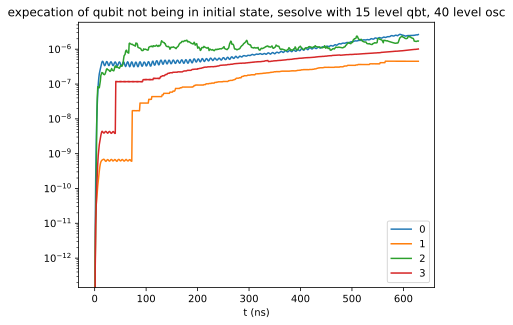

In [6]:
lists = []
for ql in [0,1,2,3]:
    pop_list = []
    for t_idx in tqdm(range(len(tlist)), desc = "t loop"):
        dm = results[ql].states[t_idx]
        pop_sum = 0
        for q in range(system.qbt.truncated_dim):
            if q != ql:
                for o in range(system.osc.truncated_dim):
                    product_state = (q, o)
                    dressed_state = system.product_to_dressed[product_state]
                    basis_state = qutip.basis(dm.dims[0][0], dressed_state)
                    expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
                    pop_sum += expectation_value

        pop_list.append(pop_sum)
    # print(pop_list)
    lists.append(pop_list)
with open('../pickles/mcsolve_three_outcome_state_leakage_list.pkl', 'wb') as file:
    pickle.dump(lists, file)
with open('../pickles/mcsolve_three_outcome_state_leakage_list.pkl', 'rb') as file:
    lists = pickle.load(file)


for ql,pop_list in enumerate(lists): 
    plt.plot(tlist,pop_list,label = f"{ql}")
plt.yscale('log')
plt.legend()
plt.title('expecation of qubit not being in initial state, sesolve with 15 level qbt, 40 level osc')
plt.xlabel('t (ns)')

In [7]:
lists = []
for ql in [0,1,2,3]:
    pops_list = [[] for _ in range(system.qbt.truncated_dim)]
    for t_idx in tqdm(range(len(tlist)), desc = "t loop"):
        dm = results[ql].states[t_idx]
        for q in range(system.qbt.truncated_dim):
            sum_at_this_t_for_this_q = 0
            for o in range(system.osc.truncated_dim):
                product_state = (q, o)
                dressed_state = system.product_to_dressed[product_state]
                basis_state = qutip.basis(dm.dims[0][0], dressed_state)
                expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
                sum_at_this_t_for_this_q += expectation_value
            pops_list[q].append(sum_at_this_t_for_this_q)
    lists.append(pops_list)

with open('../pickles/mcsolve_three_outcome_state_leakage_pop.pkl', 'wb') as file:
    pickle.dump(lists, file)
with open('../pickles/mcsolve_three_outcome_state_leakage_pop.pkl', 'rb') as file:
    lists = pickle.load(file)


t loop: 100%|██████████| 629/629 [01:51<00:00,  5.63it/s]


# On reference states:

Text(0.5, 0, 'ns')

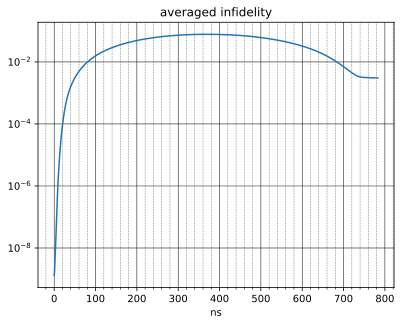

In [15]:

t_rise = 30
square_t_stop = 733
area_under_square  = square_t_stop
area_under_rise_and_fall = t_rise
t_stop = 2 * t_rise + (square_t_stop-area_under_rise_and_fall)

tot_time = int(t_stop + 20)
tlist = np.linspace(0, tot_time, tot_time)


all_results = []
for i in [2,3,4,5]:
    with open(f'../pickles/mcsolve_three_outcome_state{i}_233_summed_two_level.pkl', 'rb') as file:
        result = pickle.load(file)
    all_results.append(result)


results = [all_results[0],all_results[1],all_results[2],all_results[3]]

num_time_steps = tot_time

zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
# states_ideal  = [zero,
#                 one,
#                 (zero +  one).unit(),
#                 (zero - one).unit(),
#                 (zero + 1j * one).unit(),
#                 (zero - 1j * one).unit()  ]

states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit(), ]


def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        # fid.append(qutip.fidelity(new_dm, dm_ideal))
        fid.append(qutip.fidelity(dm, gate*dm_ideal))
    return 1-sum(fid)/len(fid)


from scipy.optimize import minimize

infidelity = []
phase = []
for idx in range(num_time_steps):
    dms = [result.states[idx] for result in results]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity.append(opt_result.fun)
    phase.append(opt_result.x[0])


plt.plot(results[0].times,infidelity)
plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.yscale('log')
plt.title("averaged infidelity")
plt.xlabel("ns")

Text(0.5, 0, 'ns')

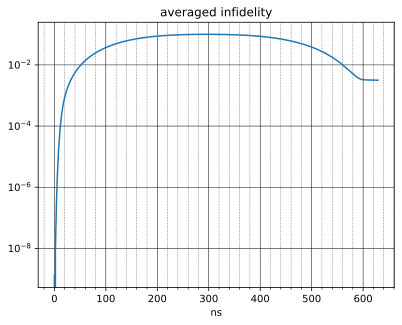

In [16]:
t_rise = 15
square_t_stop = 594.3
area_under_square  = square_t_stop
area_under_rise_and_fall = t_rise
t_stop = 2 * t_rise + (square_t_stop-area_under_rise_and_fall)

tot_time = int(t_stop + 20)
tlist = np.linspace(0, tot_time, tot_time)


all_results = []
for i in [2,3,4,5]:
    with open(f'../pickles/mcsolve_three_outcome_state{i}_summed_two_level.pkl', 'rb') as file:
        result = pickle.load(file)
    all_results.append(result)


results = [all_results[0],all_results[1],all_results[2],all_results[3]]

num_time_steps = tot_time

zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
# states_ideal  = [zero,
#                 one,
#                 (zero +  one).unit(),
#                 (zero - one).unit(),
#                 (zero + 1j * one).unit(),
#                 (zero - 1j * one).unit()  ]

states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit(), ]


def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        # fid.append(qutip.fidelity(new_dm, dm_ideal))
        fid.append(qutip.fidelity(dm, gate*dm_ideal))
    return 1-sum(fid)/len(fid)


from scipy.optimize import minimize

infidelity = []
phase = []
for idx in range(num_time_steps):
    dms = [result.states[idx] for result in results]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity.append(opt_result.fun)
    phase.append(opt_result.x[0])


plt.plot(results[0].times,infidelity)
plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.yscale('log')
plt.title("averaged infidelity")
plt.xlabel("ns")

Processing through tlist: 100%|██████████| 629/629 [00:02<00:00, 229.44it/s]


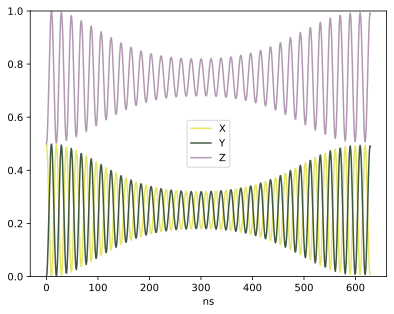

In [9]:
errors = {
    'X': [],
    'Y': [],
    'Z': []
}
inner_product_vals_dict = {
    'X': [],
    'Y': [],
    'Z': []
}

Paulis = [qutip.sigmax(),qutip.sigmay(),qutip.sigmaz()]
    
colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]

for idx in tqdm(range(len(results[0].times)), desc='Processing through tlist'):
    # dms = [all_results[2].states[idx],
    #        all_results[3].states[idx],
    #        all_results[4].states[idx],
    #        all_results[5].states[idx],
    #        all_results[6].states[idx],
    #        all_results[7].states[idx]]
    dms = [all_results[0].states[idx],
           all_results[1].states[idx],
           all_results[2].states[idx],
           all_results[3].states[idx]]
    gate = qutip.qip.operations.phasegate(theta=phase[idx])
    for P, Pauli in zip(['X','Y','Z'],Paulis):
        inner_product_vals = []
        for state_ideal, dm in zip(
            states_ideal,
            [dms[0],dms[1],dms[2],dms[3]]
            ):
            the_second_term = Pauli * qutip.ket2dm(state_ideal) * Pauli.dag()                    
            dm = gate * dm * gate.dag()
            inner_product = (the_second_term * dm.dag()).tr()
            inner_product_vals.append(inner_product)
        errors[P].append(sum(inner_product_vals)/len(inner_product_vals))
        inner_product_vals_dict[P].append(inner_product_vals)

plt.plot(results[0].times,errors['X'],label = 'X',color = colors[0])
plt.plot(results[0].times,errors['Y'],label = 'Y',color = colors[1])
plt.plot(results[0].times,errors['Z'],label = 'Z',color = colors[2])
plt.xlabel("ns")
plt.ylim(0,1)
plt.legend()


In [44]:
inner_product_vals_dict['X'][0]

[0.0,
 0.0,
 0.9999999948058698,
 0.9999999948058698,
 5.194129931718194e-09,
 5.194129931718194e-09]

In [45]:
errors['X'][0]

0.33333333333333326

In [46]:
qutip.sigmax() * qutip.ket2dm(states_ideal[2]) * qutip.sigmax().dag()     *    qutip.ket2dm(states_ideal[2]).dag()

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[0.5 0.5]
 [0.5 0.5]]

In [50]:
qutip.sigmax() * qutip.ket2dm(states_ideal[3]) * qutip.sigmax().dag()     *    qutip.ket2dm(states_ideal[3]).dag()

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[ 0.5 -0.5]
 [-0.5  0.5]]

In [65]:
qutip.sigmax() * qutip.ket2dm(states_ideal[4]) * qutip.sigmax().dag()     *    qutip.ket2dm(states_ideal[4]).dag()

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[0. 0.]
 [0. 0.]]

In [47]:
(qutip.sigmax() * qutip.ket2dm(states_ideal[2]) * qutip.sigmax().dag()     *    qutip.ket2dm(states_ideal[2]).dag()).tr()

0.9999999999999996

In [49]:
(qutip.sigmax() * qutip.ket2dm(states_ideal[3]) * qutip.sigmax().dag()     *    qutip.ket2dm(states_ideal[3]).dag()).tr()

0.9999999999999996

# Bob's method

Processing through tlist: 100%|██████████| 629/629 [00:00<00:00, 903.15it/s]
 /home/jiakai/.local/lib/python3.10/site-packages/matplotlib/cbook/__init__.py: 1340

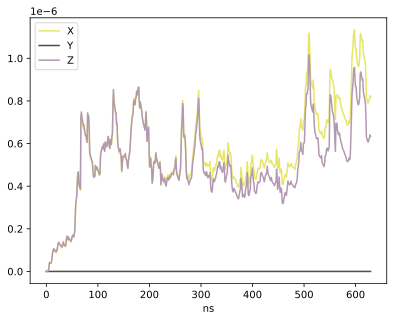

In [64]:
results = [all_results[2],
        all_results[3]]
errors = {
    'X': [],
    'Y': [],
    'Z': []
}
for t in tqdm(range(len(results[0].times)), desc='Processing through tlist'):
    gate = qutip.qip.operations.phasegate(theta=phase[idx])

    M = np.zeros((2,2))
    M[0,0] = (qutip.ket2dm(states_ideal[0])  *  gate * results[0].states[t] * gate.dag()).tr()
    M[0,1] = (qutip.ket2dm(states_ideal[0])  *  gate * results[1].states[t] * gate.dag()).tr()
    M[1,0] = (qutip.ket2dm(states_ideal[1])  *  gate * results[0].states[t] * gate.dag()).tr()
    M[1,1] = (qutip.ket2dm(states_ideal[1])  *  gate * results[1].states[t] * gate.dag()).tr()
    M = qutip.Qobj(M)
    for P, Pauli in zip(['X','Y','Z'],Paulis):
        errors[P].append(1/2 * (Pauli  *  M).tr())

plt.plot(results[0].times,errors['X'],label = 'X',color = colors[0])
plt.plot(results[0].times,errors['Y'],label = 'Y',color = colors[1])
plt.plot(results[0].times,errors['Z'],label = 'Z',color = colors[2])
plt.xlabel("ns")

plt.legend()

In [117]:
for P in [qutip.sigmax(),qutip.sigmay(),qutip.sigmaz()]:
    for i in [0,1]:
        for j in [0,1]:
            a = qutip.basis(2,i)
            b = qutip.basis(2,j)
            state = a*b.dag() 
            print(( P * state * P.dag()   *  state.dag()   ).tr())

    print('\n\n')

0.0
0.0
0.0
0.0



0.0
0.0
0.0
0.0



1.0
-1.0
-1.0
1.0



